In [37]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler ,OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

In [38]:
df=pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1.0,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0.0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1.0,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1.0,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1.0,106,0,1.9,1,3,2,0


In [39]:
num_of_na=df.isna().sum()
print(num_of_na)
num_of_dub=df.duplicated().sum()
print(num_of_dub)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     1
thalach     0
exang       0
oldpeak     2
slope       0
ca          0
thal        0
target      0
dtype: int64
720


In [40]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

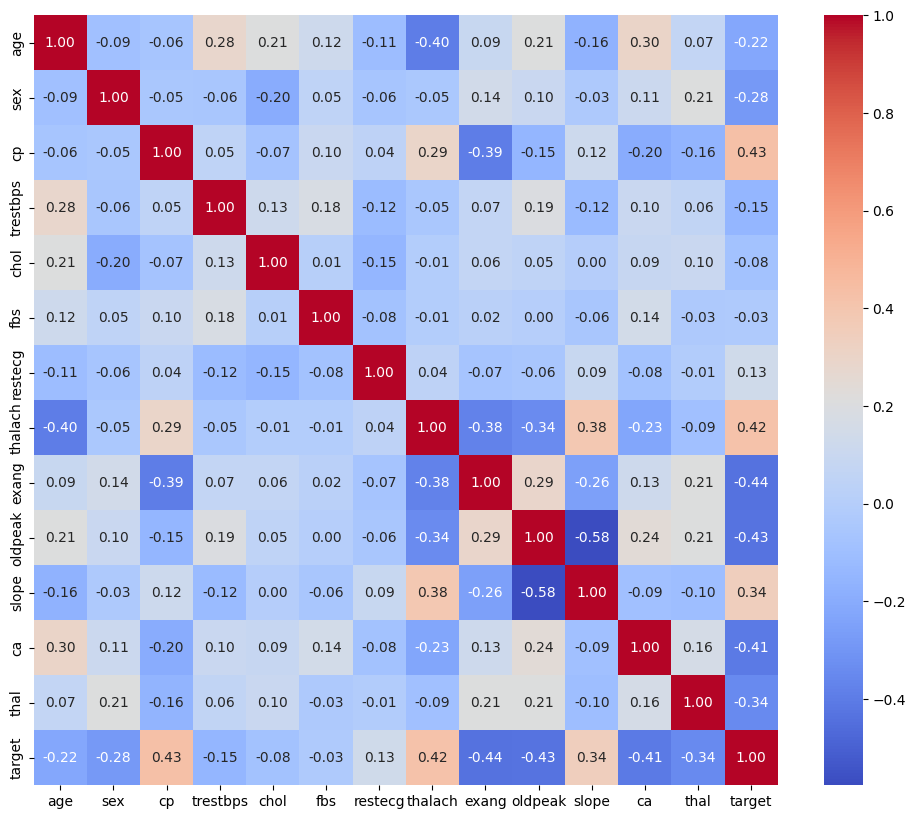

In [41]:
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

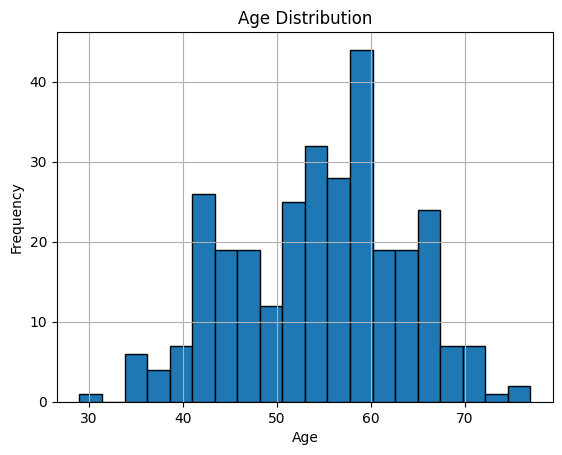

In [42]:
df['age'].hist(bins=20, edgecolor = 'black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

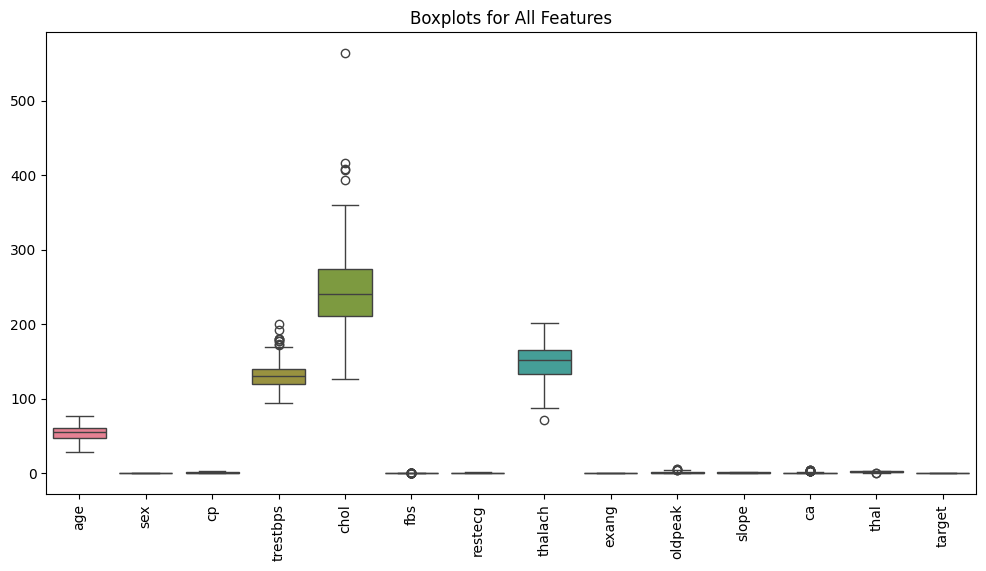

In [43]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplots for All Features")
plt.show()

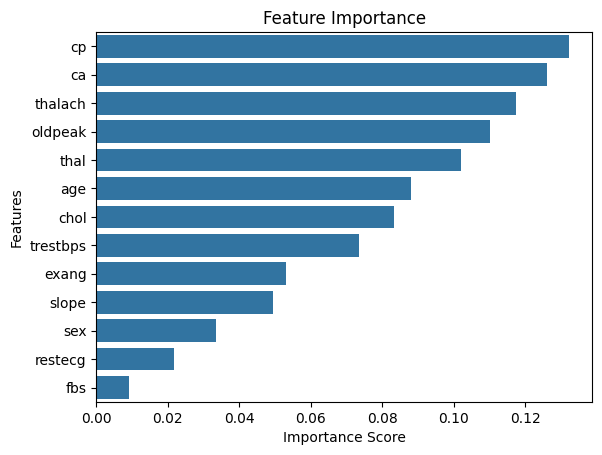

In [44]:
X = df.drop('target', axis=1)
y = df['target']

model = RandomForestClassifier()
model.fit(X, y)

# Get feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

# Plot
sns.barplot(x=importance, y=importance.index)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [45]:
df.drop(columns=['trestbps','fbs','chol', 'restecg'], inplace=True)
num_cols = ['age','thalach','oldpeak']
cat_cols = ['sex', 'cp', 'exang', 'slope', 'ca', 'thal']

In [46]:
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [33]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_cat = encoder.fit_transform(df[cat_cols])
encoded_cat_df = pd.DataFrame(encoded_cat, columns=encoder.get_feature_names_out(cat_cols))
df = pd.concat([df.drop(columns=cat_cols), encoded_cat_df], axis=1)
df.head()

,age,thalach,oldpeak,target,sex_0,sex_1,cp_0,cp_1,cp_2,cp_3,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,0.479167,0.740458,0.161290,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.500000,0.641221,0.500000,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.854167,0.412214,0.419355,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.666667,0.687023,0.000000,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.687500,0.267176,0.306452,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [34]:
df.to_csv("clean_data.csv", index=False)

In [35]:
print(df.describe())

              age     thalach     oldpeak      target       sex_0       sex_1  \
count  302.000000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean     0.529594    0.599767    0.168233    0.543046    0.317881    0.682119   
std      0.188499    0.174836    0.187331    0.498970    0.466426    0.466426   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.395833    0.475191    0.000000    0.000000    0.000000    0.000000   
50%      0.552083    0.622137    0.129032    1.000000    0.000000    1.000000   
75%      0.666667    0.725191    0.258065    1.000000    1.000000    1.000000   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

             cp_0        cp_1        cp_2        cp_3  ...     slope_2  \
count  302.000000  302.000000  302.000000  302.000000  ...  302.000000   
mean     0.473510    0.165563    0.284768    0.076159  ...    0.466887   
std      0.500126    0.372305    0.452053    0.2